# Análise Exploratória De Dados (EDA)

Objetivo desta fase é entender as features do dataset de clientes da Calcomm

## 1 - Configuração Do Ambiente

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Bibliotecas básicas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Estatística
from scipy import stats

## 2 - Características do dataset bruto

O dataset usado para a experimentação foi elaborado através de fontes de dados internas de operações e vendas da Calcomm.

### Features disponíveis

O dataset bruto apresenta 33 colunas de dados de identificação dos clientes, demografia e características de serviço.

–	CustomerID: código de identificaão do cliente
–	Count: condado
–	Country: país
–	State: estado
–	City: cidade
–	Zip Code: CEP do endereço
–	Lat Long: latitude e longitude combinadas do endereço do cliente
–	Latitude: latitude do endereço do cliente
–	Longitude: longitude do endereço do cliente
–	Gender: sexo do cliente (m/f)
–	Senior Citizen: a partir de 65 anos (s/n)
–	Partner: Possui companheiro (s/n)
–	Dependents: Possui dependentes (s/n)
–	Tenure Months: tempo de serviço (meses)
–	Phone Service: Possui serviço de telefonia (s/n)
–	Multiple Lines: possui múltiplas linhas telefônicas (s/n)
–	Internet Service: Possui serviço de internet (s/n)
–	Online Security: Possui serviço de segurança online (s/n)
–	Online Backup: Possui serviço de backup online (s/n)
–	Device Protection: Possui serviço de proteção de dispositivo (s/n)
–	Tech Support: Possui serviço suporte técnico (s/n)
–	Streaming TV: Possui serviço de streaming de programas de TV (s/n)
–	Streaming Movies: Possui serviço de streaming de filmes (s/n)
–	Contract: tipo de contrato de fidelidade (mensal, anual ou bienal)
–	Paperless Billing: fatura digital (s/n)
–	Payment Method: método de pagamento (débito automático, cartão de crédito ou pix)
–	Monthly Charges: custo menal (número, floating)
–	Total Charges: despesas trimestrais (número, floating)
–	Churn Label: indicador de churn, cliente deixou a Calcomm no trimestre (s/n)
–	Churn Value: indicador numérico de churn (0/1)
–	Churn Score: indicador numérico de probabilidade de saída (churn) (0-100)
–	CLTV: Customer Lifetime Value (numérico)
–	Churn Reason: motivo da saída (string)

### Observações

Obs 1
Obs 2


In [22]:
# Aponta novo dataset com dados brutos
path = "../data/raw/Telco_customer_churn.csv"

# Carrega dataset em um dataframe pandas
df = pd.read_csv(path)

# Exibe informações sobre o dataset
print(f"Shape dos dados: {df.shape}")
print(f"Nome das colunas:\n{df.columns.tolist()}")

# Exibe primeiras linhas do dataset
df.head(10)

Shape dos dados: (7043, 33)
Nome das colunas:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868",34.066367,-118.309868,Female,...,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,1,78,5925,Competitor offered higher download speeds
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,...,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,100,5433,Competitor offered more data
7,1066-JKSGK,1,United States,California,Los Angeles,90024,"34.066303, -118.435479",34.066303,-118.435479,Male,...,Month-to-month,No,Mailed check,20.15,20.15,Yes,1,92,4832,Competitor made better offer
8,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843",34.099869,-118.326843,Male,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,1,77,5789,Competitor had better devices
9,8665-UTDHZ,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Month-to-month,No,Electronic check,30.20,30.2,Yes,1,97,2915,Competitor had better devices


Os dados brutos  mostram ...

In [23]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null 

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## 3 - Análise exploratória

### 3.1 - Valores ausentes no dataset

O EDA exclui cálculo da coluna de motivo do churn quando não ocorreu o churn.

In [29]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

# 'Churn Reason' só é esperado para clientes que fizeram churn.
# Recalcula o missing apenas sobre a base de churners para não inflar o percentual.
if 'Churn Reason' in missing_values.index:
    churners = df[df['Churn Label'] == 'Yes']
    reason_missing = churners['Churn Reason'].isnull().sum()
    reason_pct = round(reason_missing / len(churners) * 100, 2)
    missing_values.loc['Churn Reason', 'Missing_Count'] = reason_missing
    missing_values.loc['Churn Reason', 'Missing_Percentage'] = reason_pct
    missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
        by='Missing_Percentage', ascending=False
    )

if len(missing_values) > 0:
    print(missing_values)
    print("\nNota: o percentual de 'Churn Reason' é calculado apenas sobre churners (Churn Label = Yes).")
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

=== ANÁLISE DE MISSING VALUES ===

Nenhum missing value detectado!


### 3.2 - Análise da variável target

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Churn não ocorreu (0): 73.46%
Houve churn (1): 26.54%


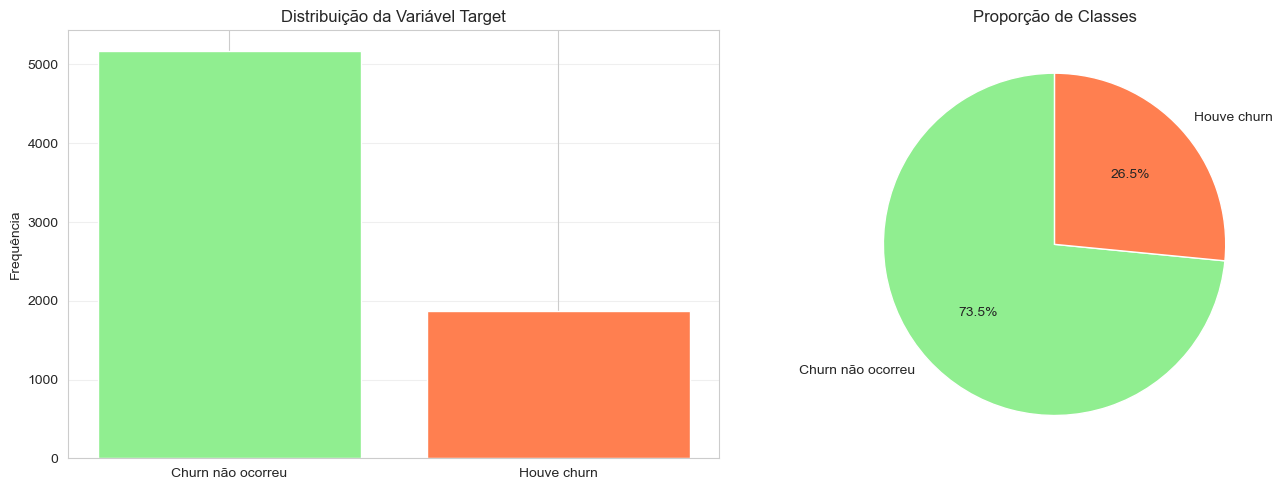


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [30]:
# Análise da variável alvo - Churn

# Renomear variável `Churn Value` para `target`
df.rename(columns={'Churn Value': 'target'}, inplace=True)

# Converter target para binário (0 = não houve chrun, 1 = houve churn)
# No dataset original, valores > 0 indicam presença de doença
df['target'] = (df['target'] > 0).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Churn não ocorreu" if idx == 0 else "Houve churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Churn não ocorreu', 'Houve churn'], target_counts.values, color=['lightgreen', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Churn não ocorreu', 'Houve churn'], 
            autopct='%1.1f%%', colors=['lightgreen', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")

### 3.3 - Análise De Outliers

A análise de outliers permite visualizar dados com valores extremos que podem ser válidos, erros de entrada ou coleta e ajudar na decisão sobre tratamento adicional de um ou mais deles, como normalização ou exclusão.

**Métodos utilizados:**

- **Z-Score**: Identifica valores que estão a mais de 3 desvios padrão da média
- **Visualização**: Mostra boxplots para identificação visual


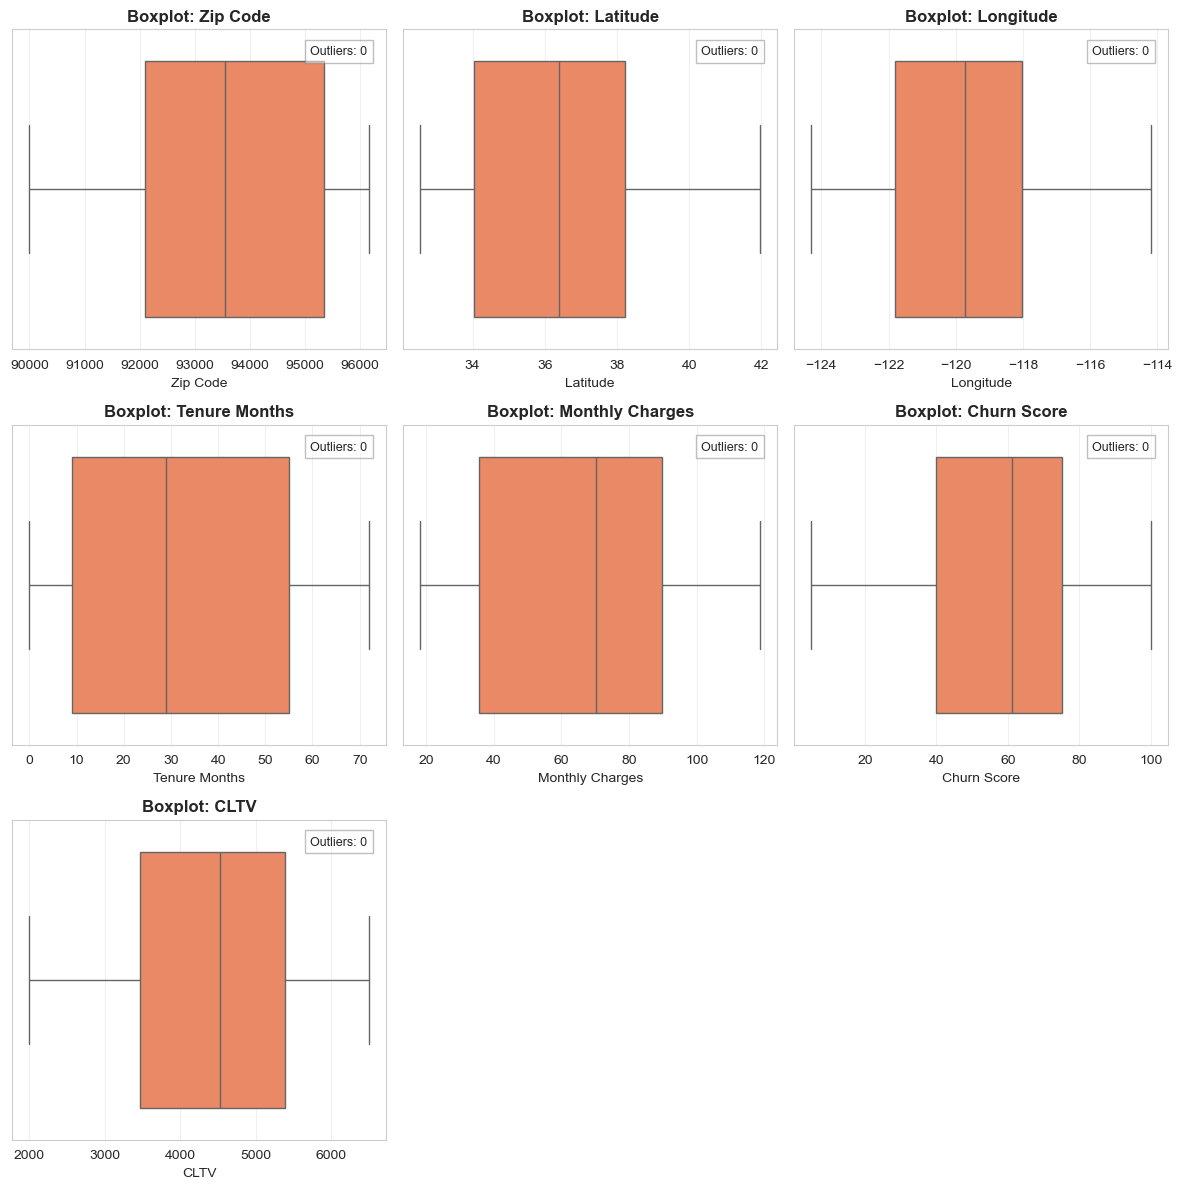

In [31]:
# Colunas numéricas (excluindo CustomerID e target que é a variável alvo). A feature "count" também não deve ser usada na análise.
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['CustomerID', 'target', "Count"], errors='ignore')

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


**Análise inicial**: Como os dados são do estado da Califórnia, os valores relacionados à localidade não deveriam apresentar outliers como indicado nos boxplot acima. O dataset trás valores de coordenadas geográficas e CEP (ZIP) similares. Caso houvesse outliers, seria necessário identificar se são estatísticos pelo modelo de distribuião de ZIP codes ou extensão territorial do estado ou se poderiam ser dados errados como um ZIP code ou coordenada distante, possivelmente erro de coleta ou entrada de dados. A análise de anomalias a seguir também contribui para esta verificação.




### 3.4 - Análise De Anomalias E Valores Inválidos

**Objetivo**: Encontrar valores em features fora de contexto na relação de churn.


In [54]:
print("=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===\n")

# Verificações de consistência baseadas em conhecimento de domínio
anomalies = []

# 1. ZIP code (deve estar entre 90000 e 96162 de acordo com https://www.unitedstateszipcodes.org/ca/)
zip_code = df[(df['Zip Code'] < 90000) | (df['Zip Code'] > 96162)]
if len(zip_code) > 0:
    anomalies.append(f"ZIP Code fora do intervalo válido para Califórnia: {len(zip_code)} casos")
    
# 2. Churn Score (ChurnScore) - valores válidos: 0-100
churn_score = df[(df['Churn Score'] < 0) | (df['Churn Score'] > 100)]
if len(churn_score) > 0:
    anomalies.append(f"Churn Score anormal: {len(churn_score)} casos")
    print(f"⚠️ Churn Score anormal detectada: {len(churn_score)} casos")
    print(f"   Valores: min={df['churn_score'].min()}, max={df['churn_score'].max()}")

# # 3. Colesterol (chol) - valores típicos: 100-400 mg/dl
# chol_anomalies = df[(df['chol'] < 100) | (df['chol'] > 400)]
# if len(chol_anomalies) > 0:
#     anomalies.append(f"Colesterol anormal: {len(chol_anomalies)} casos")
#     print(f"⚠️ Colesterol anormal detectado: {len(chol_anomalies)} casos")
#     print(f"   Valores: min={df['chol'].min()}, max={df['chol'].max()}")

# # 4. Frequência cardíaca máxima (thalch) - valores típicos: 60-220 bpm
# hr_anomalies = df[(df['thalch'] < 60) | (df['thalch'] > 220)]
# if len(hr_anomalies) > 0:
#     anomalies.append(f"Frequência cardíaca anormal: {len(hr_anomalies)} casos")
#     print(f"⚠️ Frequência cardíaca anormal detectada: {len(hr_anomalies)} casos")
#     print(f"   Valores: min={df['thalch'].min()}, max={df['thalch'].max()}")

# 5. Variáveis categóricas com valores fora do esperado
categorical_checks = {
    'Gender': ["Female", "Male"],
    'Senior Citizen': ["Yes", "No"],
    'Partner': ["Yes", "No"],
    'Dependents': ["Yes", "No"],
    'Phone Service': ["Yes", "No"],
    'Multiple Lines': ["Yes", "No", "No phone service"],
    'Internet Service': ["DSL", "Fiber optic", "No"],
    'Online Security': ["Yes", "No", "No internet service"],
    'Online Backup': ["Yes", "No", "No internet service"],
    'Device Protection': ["Yes", "No", "No internet service"],
    'Tech Support': ["Yes", "No", "No internet service"],
    'Streaming TV': ["Yes", "No", "No internet service"],
    'Streaming Movies': ["Yes", "No", "No internet service"],
    'Contract': ["Month-to-month", "One year", "Two year"],
    'Paperless Billing': ["Yes", "No"],
    'Payment Method': ["Bank transfer (automatic)", "Credit card (automatic)", "Electronic check", "Mailed check"],
}

for col, valid_values in categorical_checks.items():
    if col in df.columns:
        invalid = df[~df[col].isin(valid_values) & df[col].notna()]
        if len(invalid) > 0:
            anomalies.append(f"{col}: {len(invalid)} valores inválidos")
            print(f"⚠️ {col}: {len(invalid)} valores fora do domínio esperado {valid_values}")

if len(anomalies) == 0:
    print("✓ Nenhuma anomalia óbvia detectada nas validações de domínio!")
else:
    print(f"\n📊 Total de tipos de anomalias detectadas: {len(anomalies)}")

# Verificar duplicados
duplicates = df.duplicated().sum()
print(f"\n=== DUPLICADOS ===")
print(f"Registros duplicados: {duplicates}")
if duplicates > 0:
    print("⚠️ Considere remover ou investigar registros duplicados")

=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===

✓ Nenhuma anomalia óbvia detectada nas validações de domínio!

=== DUPLICADOS ===
Registros duplicados: 0


### 3.5 Análise de Distribuições

**Objetivo:** Entender a distribuição das variáveis numéricas e identificar assimetrias

=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

         Coluna  Skewness  Kurtosis Interpretação
       Zip Code    -0.251    -1.154        Normal
       Latitude     0.304    -1.136        Normal
      Longitude    -0.041    -1.136        Normal
  Tenure Months     0.240    -1.387        Normal
Monthly Charges    -0.221    -1.257        Normal
    Churn Score    -0.090    -1.006        Normal
           CLTV    -0.312    -0.934        Normal


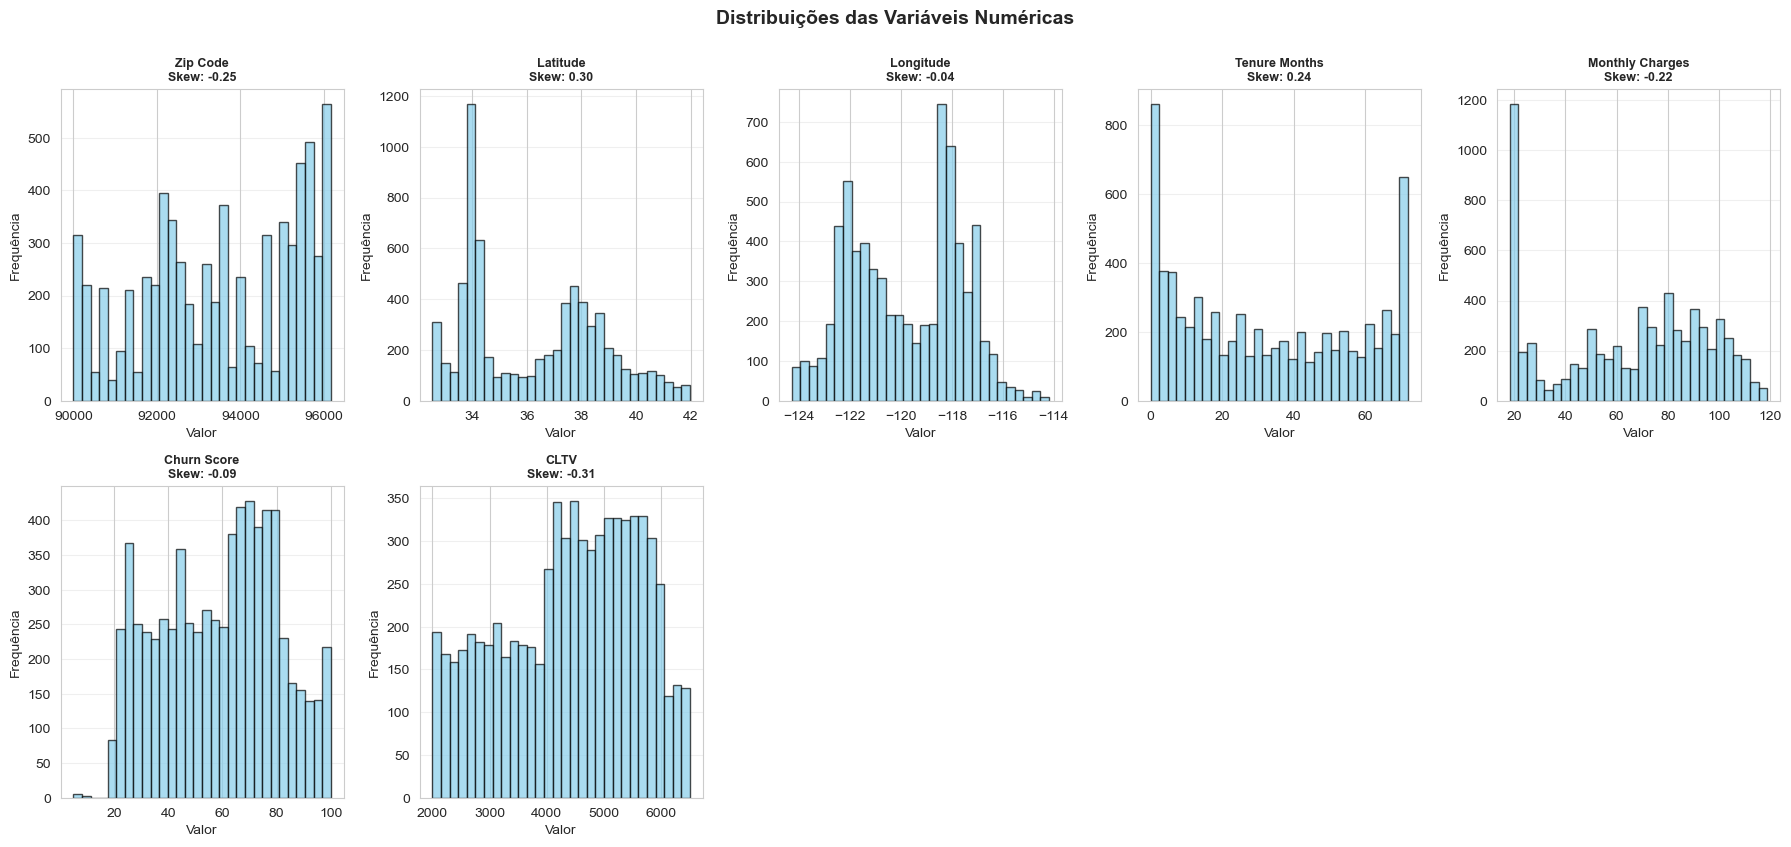

In [55]:
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.6 Análise de Correlações

**Objetivo:** Identificar relações entre variáveis e detectar multicolinearidade


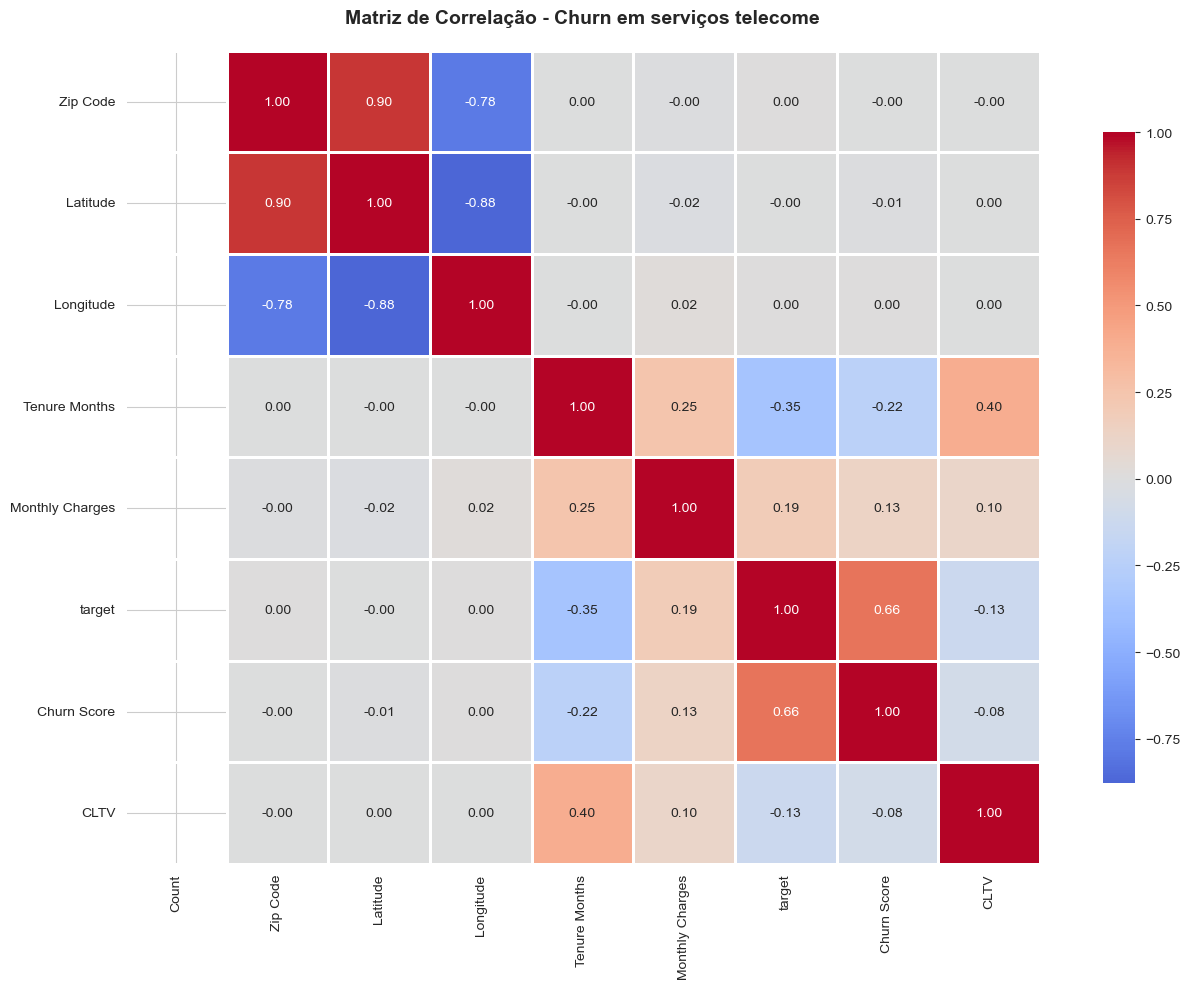

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target             1.000000
Churn Score        0.664897
Monthly Charges    0.193356
Longitude          0.004594
Zip Code           0.003346
Latitude          -0.003384
CLTV              -0.127463
Tenure Months     -0.352229
Name: target, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

    Feature 1       Feature 2  Correlação
        Count        Zip Code       1.000
     Zip Code        Latitude       1.000
     Latitude       Longitude       1.000
    Longitude   Tenure Months       1.000
Tenure Months Monthly Charges       1.000
  Churn Score            CLTV       1.000
        Count        Latitude       0.896
        Count       Longitude      -0.784
     Zip Code       Longitude      -0.877

⚠️ Alta correlação entre features pode causar multicolinearidade!


In [ ]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()
corr_numeric = corr_numeric.drop(["Count"], errors='ignore')

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Churn em serviços telecom', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")

**Observaçõe**:
- Algumas correlações podem não fazer sentido como Zip Code com Latitude e Longitude.